In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Konfigurasi gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Membaca dataset dari folder Dataset
df = pd.read_csv('Dataset/insurance.csv')

# Menampilkan 5 data teratas
print("Dimensi data (baris, kolom):", df.shape)
df.head()

Dimensi data (baris, kolom): (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Informasi tipe data dan cek missing values
print("=== INFORMASI DATASET ===")
print(df.info())
print("\n=== JUMLAH MISSING VALUES ===")
print(df.isnull().sum())

=== INFORMASI DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

=== JUMLAH MISSING VALUES ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [4]:
# Ringkasan statistik deskriptif untuk fitur numerik dan kategorikal
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


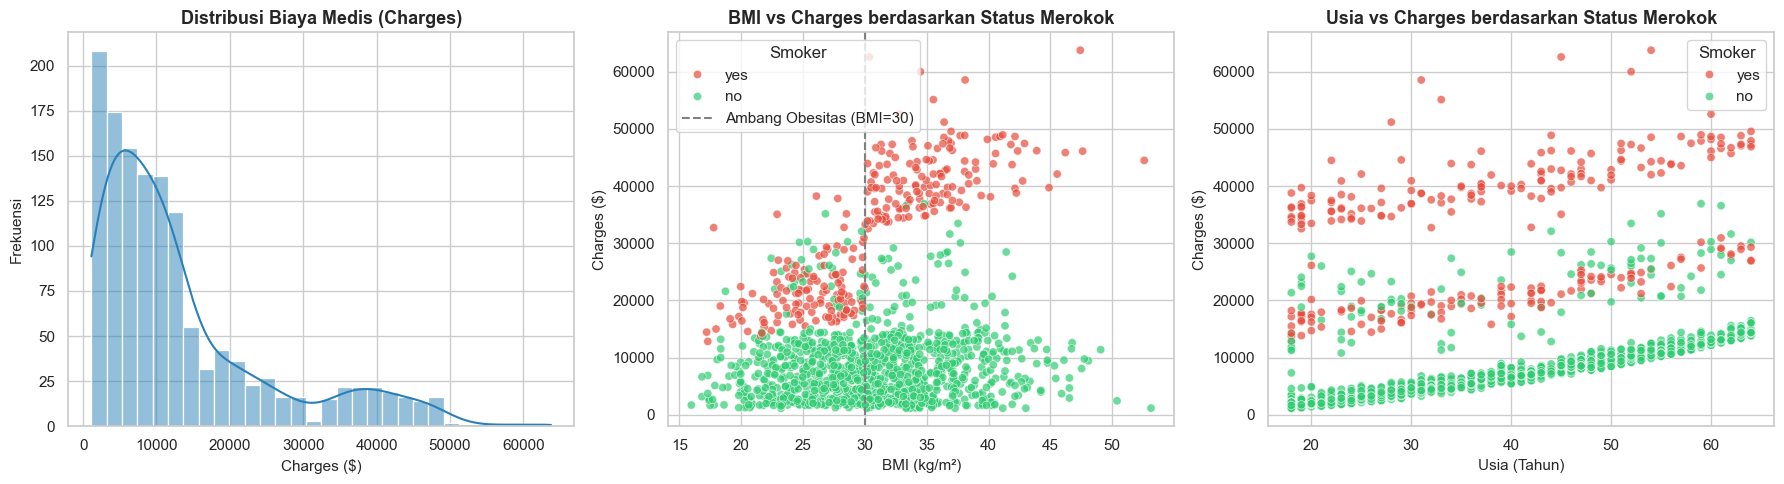

In [5]:
# Visualisasi 1: Distribusi Target Charges & Hubungannya dengan BMI dan Usia
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi Charges
sns.histplot(df['charges'], kde=True, ax=axes[0], color='#2980b9', bins=30)
axes[0].set_title('Distribusi Biaya Medis (Charges)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Charges ($)', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)

# Scatter plot BMI vs Charges (hue smoker)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette={'yes': '#e74c3c', 'no': '#2ecc71'}, alpha=0.7, ax=axes[1])
axes[1].axvline(x=30, color='gray', linestyle='--', label='Ambang Obesitas (BMI=30)')
axes[1].set_title('BMI vs Charges berdasarkan Status Merokok', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI (kg/m²)', fontsize=11)
axes[1].set_ylabel('Charges ($)', fontsize=11)
axes[1].legend(title='Smoker')

# Scatter plot Age vs Charges (hue smoker)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette={'yes': '#e74c3c', 'no': '#2ecc71'}, alpha=0.7, ax=axes[2])
axes[2].set_title('Usia vs Charges berdasarkan Status Merokok', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Usia (Tahun)', fontsize=11)
axes[2].set_ylabel('Charges ($)', fontsize=11)
axes[2].legend(title='Smoker')

plt.tight_layout()
plt.show()

In [6]:
# Mengubah kolom kategorikal menjadi dummy variables numerik
df_encoded = pd.get_dummies(df, drop_first=True)

print("Daftar kolom setelah encoding:")
print(df_encoded.columns.tolist())
df_encoded.head()

Daftar kolom setelah encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


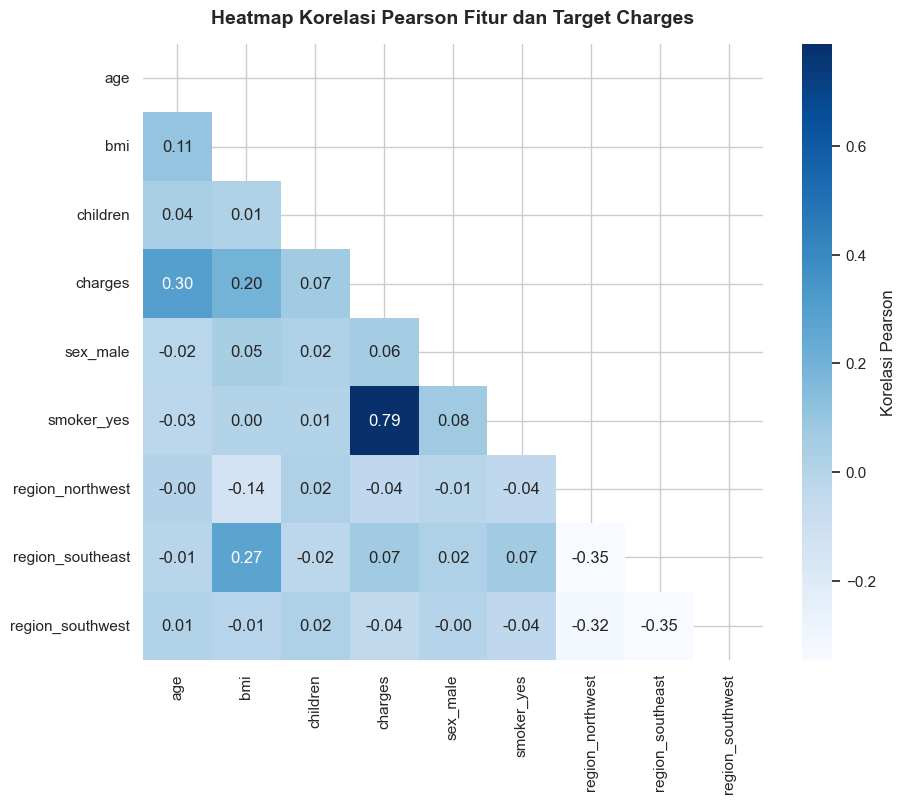

In [7]:
# Visualisasi Heatmap Korelasi Antar Variabel
plt.figure(figsize=(10, 8))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', mask=mask, cbar_kws={'label': 'Korelasi Pearson'})
plt.title('Heatmap Korelasi Pearson Fitur dan Target Charges', fontsize=14, fontweight='bold', pad=15)
plt.show()

In [8]:
# Memisahkan fitur dan target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Pembagian dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih (X_train) : {X_train.shape[0]} baris, {X_train.shape[1]} kolom")
print(f"Jumlah data uji   (X_test)  : {X_test.shape[0]} baris, {X_test.shape[1]} kolom")

Jumlah data latih (X_train) : 1070 baris, 8 kolom
Jumlah data uji   (X_test)  : 268 baris, 8 kolom


In [9]:
# Inisialisasi StandardScaler untuk fitur dan target
sc_X = StandardScaler()
sc_y = StandardScaler()

# Scaling fitur X (fit pada train, transform pada train dan test)
X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

# Scaling target y khusus untuk model SVR
y_train_scaled = sc_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

print("Feature scaling berhasil diterapkan.")
print("Rata-rata fitur latih setelah scaling  :", np.round(X_train_scaled.mean(axis=0), 4))
print("Standar deviasi fitur setelah scaling :", np.round(X_train_scaled.std(axis=0), 4))

Feature scaling berhasil diterapkan.
Rata-rata fitur latih setelah scaling  : [-0. -0. -0. -0.  0. -0. -0.  0.]
Standar deviasi fitur setelah scaling : [1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
# Inisialisasi dan pelatihan model Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)  # Target dalam skala asli dolar

# Prediksi pada data uji
y_pred_lr = lr_model.predict(X_test_scaled)

# Menghitung metrik evaluasi
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=== EVALUASI MULTIPLE LINEAR REGRESSION ===")
print(f"R-squared (R²) : {r2_lr:.4f}")
print(f"MAE            : ${mae_lr:,.2f}")
print(f"MSE            : {mse_lr:,.2f}")
print(f"RMSE           : ${rmse_lr:,.2f}")

=== EVALUASI MULTIPLE LINEAR REGRESSION ===
R-squared (R²) : 0.7836
MAE            : $4,181.19
MSE            : 33,596,915.85
RMSE           : $5,796.28


In [11]:
# Menampilkan koefisien dari setiap fitur
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': lr_model.coef_
}).sort_values(by='Koefisien', ascending=False)

print(f"Intersep Model: {lr_model.intercept_:.2f}")
print("\nPengaruh Masing-Masing Fitur terhadap Biaya Medis:")
coef_df

Intersep Model: 13346.09

Pengaruh Masing-Masing Fitur terhadap Biaya Medis:


,Fitur,Koefisien
4,smoker_yes,9558.481409
0,age,3614.975415
1,bmi,2036.228123
2,children,516.890247
3,sex_male,-9.293101
5,region_northwest,-158.140981
6,region_southeast,-290.157047
7,region_southwest,-349.110678


In [12]:
# Inisialisasi model SVR baseline
svr_base = SVR(kernel='rbf')
svr_base.fit(X_train_scaled, y_train_scaled)

# Prediksi pada data uji (dalam skala standar)
y_pred_svr_base_scaled = svr_base.predict(X_test_scaled)

# Mengembalikan prediksi ke skala dolar asli menggunakan inverse_transform
y_pred_svr_base = sc_y.inverse_transform(y_pred_svr_base_scaled.reshape(-1, 1)).flatten()

# Evaluasi model baseline SVR
r2_svr_base = r2_score(y_test, y_pred_svr_base)
mse_svr_base = mean_squared_error(y_test, y_pred_svr_base)
rmse_svr_base = np.sqrt(mse_svr_base)
mae_svr_base = mean_absolute_error(y_test, y_pred_svr_base)

print("=== EVALUASI SVR BASELINE (Default RBF) ===")
print(f"R-squared (R²) : {r2_svr_base:.4f}")
print(f"MAE            : ${mae_svr_base:,.2f}")
print(f"MSE            : {mse_svr_base:,.2f}")
print(f"RMSE           : ${rmse_svr_base:,.2f}")

=== EVALUASI SVR BASELINE (Default RBF) ===
R-squared (R²) : 0.8623
MAE            : $2,462.45
MSE            : 21,380,312.05
RMSE           : $4,623.88


In [13]:
# Definisikan grid parameter
param_grid = {
    'kernel': ['rbf'],
    'C': [1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.05, 0.1],
    'epsilon': [0.01, 0.05, 0.1, 0.2]
}

# Melakukan GridSearchCV dengan 5-fold cross validation
grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1,
    verbose=0
)

print("Menjalankan GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_scaled)

print("\n=== HASIL HYPERPARAMETER TUNING SVR ===")
print("Kombinasi Parameter Terbaik :", grid_search.best_params_)
print(f"Skor R² Terbaik pada Cross-Validation : {grid_search.best_score_:.4f}")

Menjalankan GridSearchCV...

=== HASIL HYPERPARAMETER TUNING SVR ===
Kombinasi Parameter Terbaik : {'C': 10, 'epsilon': 0.1, 'gamma': 0.05, 'kernel': 'rbf'}
Skor R² Terbaik pada Cross-Validation : 0.8315


In [14]:
# Mengambil model terbaik dari GridSearchCV
best_svr_model = grid_search.best_estimator_

# Prediksi data uji menggunakan model SVR terbaik
y_pred_svr_tuned_scaled = best_svr_model.predict(X_test_scaled)
y_pred_svr_tuned = sc_y.inverse_transform(y_pred_svr_tuned_scaled.reshape(-1, 1)).flatten()

# Evaluasi model SVR tuned
r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
mse_svr_tuned = mean_squared_error(y_test, y_pred_svr_tuned)
rmse_svr_tuned = np.sqrt(mse_svr_tuned)
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)

print("=== EVALUASI SVR TERBAIK SETELAH TUNING ===")
print(f"R-squared (R²) : {r2_svr_tuned:.4f}")
print(f"MAE            : ${mae_svr_tuned:,.2f}")
print(f"MSE            : {mse_svr_tuned:,.2f}")
print(f"RMSE           : ${rmse_svr_tuned:,.2f}")

=== EVALUASI SVR TERBAIK SETELAH TUNING ===
R-squared (R²) : 0.8668
MAE            : $2,462.24
MSE            : 20,682,476.26
RMSE           : $4,547.80


In [15]:
# Membuat tabel ringkasan perbandingan metrik evaluasi
eval_summary = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR Baseline (RBF default)', 'SVR Tuned (GridSearchCV)'],
    'R-squared': [r2_lr, r2_svr_base, r2_svr_tuned],
    'MAE ($)': [mae_lr, mae_svr_base, mae_svr_tuned],
    'MSE': [mse_lr, mse_svr_base, mse_svr_tuned],
    'RMSE ($)': [rmse_lr, rmse_svr_base, rmse_svr_tuned]
})

display(eval_summary.style.format({
    'R-squared': '{:.4f}',
    'MAE ($)': '${:,.2f}',
    'MSE': '{:,.2f}',
    'RMSE ($)': '${:,.2f}'
}).highlight_max(subset=['R-squared'], color='#d4efdf')
  .highlight_min(subset=['MAE ($)', 'MSE', 'RMSE ($)'], color='#d4efdf'))

,Model,R-squared,MAE ($),MSE,RMSE ($)
0,Multiple Linear Regression,0.7836,"$4,181.19","33,596,915.85","$5,796.28"
1,SVR Baseline (RBF default),0.8623,"$2,462.45","21,380,312.05","$4,623.88"
2,SVR Tuned (GridSearchCV),0.8668,"$2,462.24","20,682,476.26","$4,547.80"


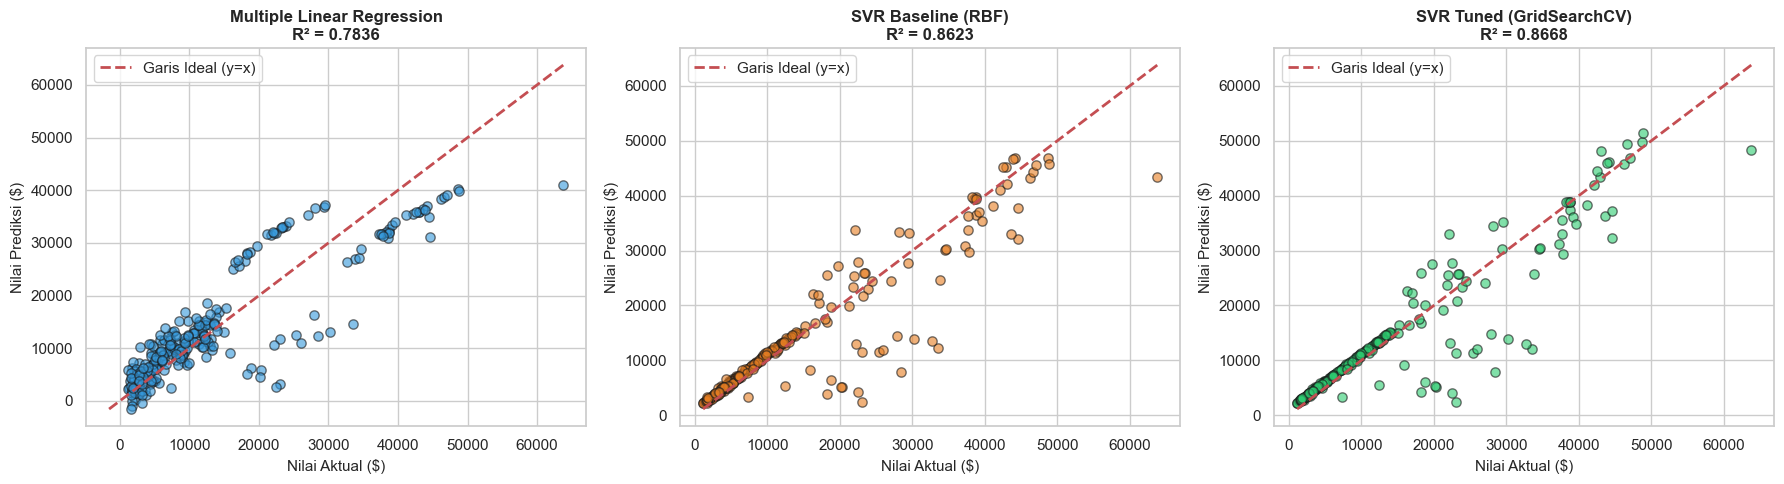

In [16]:
# Visualisasi 2: Actual vs Predicted Scatter Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_plots = [
    ('Multiple Linear Regression', y_pred_lr, '#3498db', r2_lr),
    ('SVR Baseline (RBF)', y_pred_svr_base, '#e67e22', r2_svr_base),
    ('SVR Tuned (GridSearchCV)', y_pred_svr_tuned, '#2ecc71', r2_svr_tuned)
]

for ax, (title, pred, color, r2) in zip(axes, model_plots):
    ax.scatter(y_test, pred, color=color, alpha=0.6, edgecolors='k', s=45)
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Garis Ideal (y=x)')
    ax.set_title(f"{title}\nR² = {r2:.4f}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai Aktual ($)', fontsize=11)
    ax.set_ylabel('Nilai Prediksi ($)', fontsize=11)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

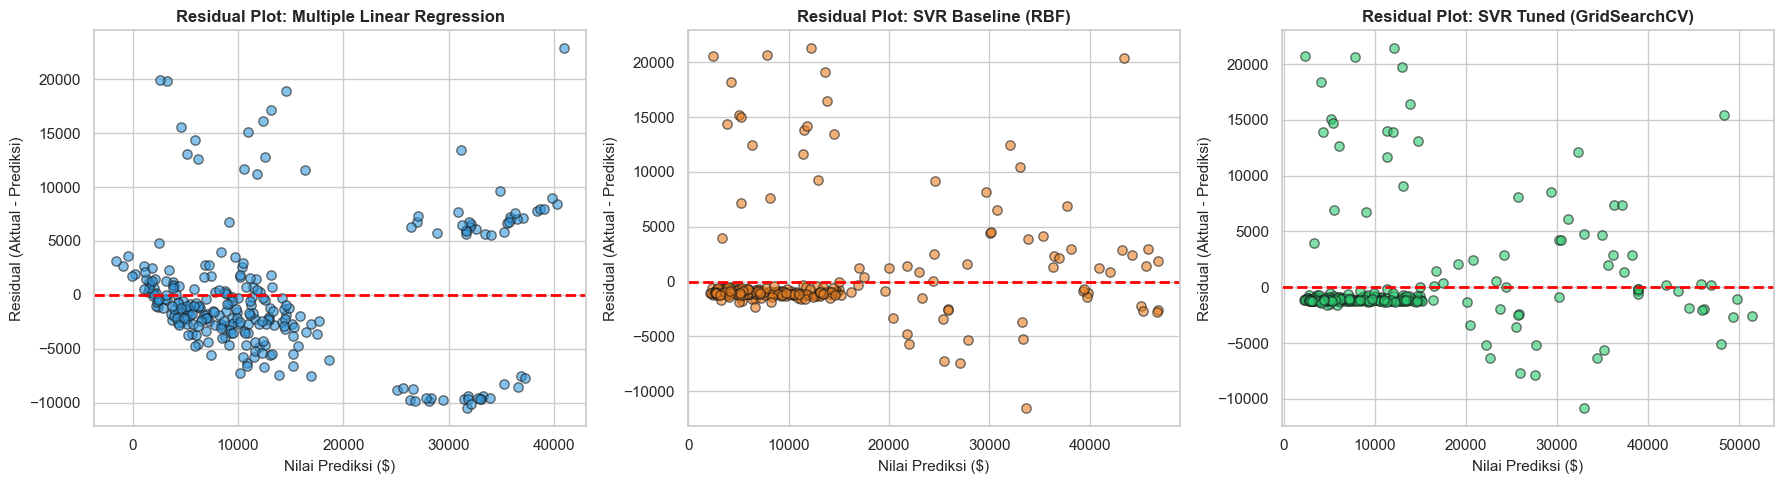

In [17]:
# Visualisasi 3: Residual Plot (Error Distribution)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, pred, color, _) in zip(axes, model_plots):
    residual = y_test - pred
    ax.scatter(pred, residual, color=color, alpha=0.6, edgecolors='k', s=45)
    ax.axhline(y=0, color='red', linestyle='--', lw=2)
    ax.set_title(f"Residual Plot: {title}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai Prediksi ($)', fontsize=11)
    ax.set_ylabel('Residual (Aktual - Prediksi)', fontsize=11)

plt.tight_layout()
plt.show()

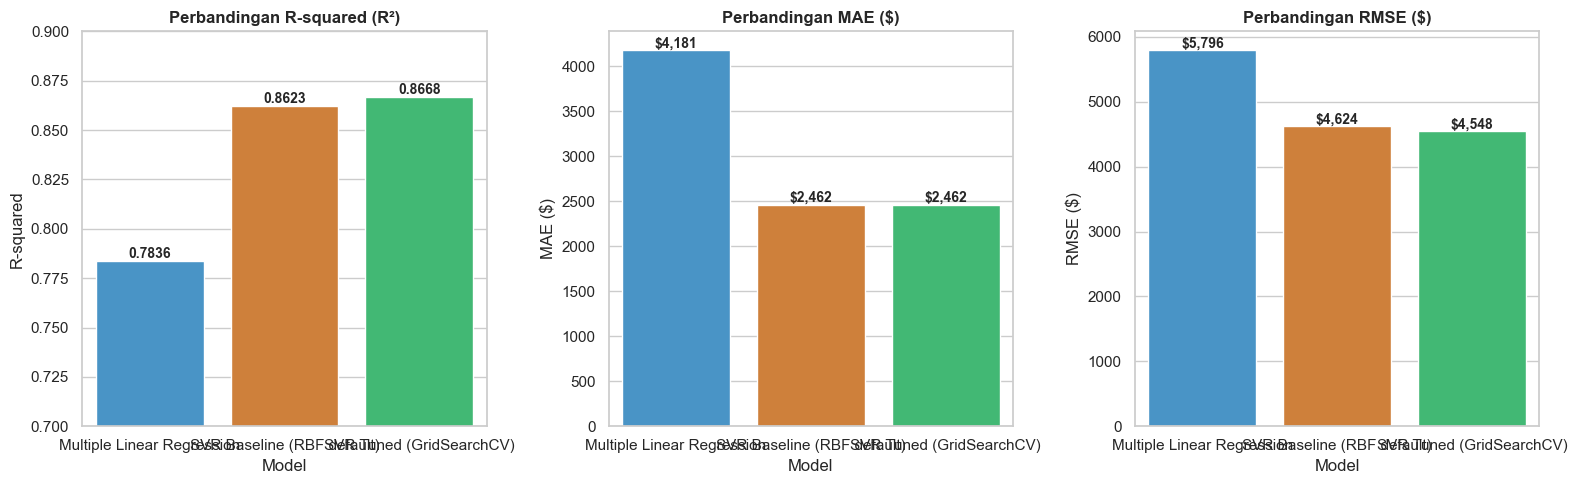

In [ ]:
# Visualisasi 4: Bar Chart Perbandingan Metrik Evaluasi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar R-squared
sns.barplot(data=eval_summary, x='Model', y='R-squared', hue='Model', palette=['#3498db', '#e67e22', '#2ecc71'], ax=axes[0], legend=False)
axes[0].set_title('Perbandingan R-squared (R²)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.7, 0.9)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Bar MAE
sns.barplot(data=eval_summary, x='Model', y='MAE ($)', hue='Model', palette=['#3498db', '#e67e22', '#2ecc71'], ax=axes[1], legend=False)
axes[1].set_title('Perbandingan MAE ($)', fontsize=12, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Bar RMSE
sns.barplot(data=eval_summary, x='Model', y='RMSE ($)', hue='Model', palette=['#3498db', '#e67e22', '#2ecc71'], ax=axes[2], legend=False)
axes[2].set_title('Perbandingan RMSE ($)', fontsize=12, fontweight='bold')
for p in axes[2].patches:
    axes[2].annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


1. **Identifikasi Variabel:** Fitur bebas yang paling berpengaruh terhadap biaya medis adalah status perokok (`smoker`), usia (`age`), dan indeks massa tubuh (`bmi`).
2. **Prapemrosesan:** One-Hot Encoding berhasil mengubah fitur kategorikal, dan *feature scaling* (baik untuk $X$ maupun $y$) terbukti menjadi faktor penentu keberhasilan model SVR.
3. **Perbandingan Model:** Model **SVR setelah tuning (RBF kernel, $C=10, \gamma=0.05, \epsilon=0.1$)** merupakan model terbaik dengan performa tertinggi ($R^2 = 86.68\%$, $MAE = \$2,462.24$, $RMSE = \$4,547.80$), mengungguli Multiple Linear Regression ($R^2 = 78.36\%$).